In [1]:
# --- Core Python ---
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path
Libraries loaded successfully


In [12]:
np.floor(5*0.1)

np.float64(0.0)

In [2]:
feature_matrix = pd.read_pickle(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\raw-breathmetrics-features-session-2sec")
feature_matrix.columns

Index(['WindowID', 'Start', 'Stop', 'Duration', 'n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_breathing_rate', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol', 'cv_tidal_vol', 'minute_ventilation', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'exhale_duty_cycle', 'Trial', 'Subject', 'Condition', 'Rank', 'Type', 'session_duration_sec', 'n_breaths_total', 'WindowSec', 'n_bouts_anogenital_sniffing', 'n_bouts_body_sniffing', 'n_bouts_facial_sniffing', 'total_dur_anogenital_sniffing', 'total_dur_body_sniffing', 'total_dur_facial_sniffing'], dtype='object')

In [3]:
print(feature_matrix["Condition"].value_counts())

Condition
RI1     784
RI2     737
BLRI    694
Name: count, dtype: int64


In [15]:
feature_matrix

,WindowID,Start,Stop,Duration,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_breathing_rate,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,ie_ratio,mean_peak_insp_flow,mean_peak_exp_flow,cv_peak_insp_flow,mean_inhale_vol,mean_exhale_vol,mean_tidal_vol,cv_tidal_vol,minute_ventilation,pct_breaths_with_inhale_pause,mean_inhale_pause_dur_sec,cv_inhale_pause_dur,inhale_pause_duty_cycle,pct_breaths_with_exhale_pause,mean_exhale_pause_dur_sec,cv_exhale_pause_dur,exhale_pause_duty_cycle,inhale_duty_cycle,exhale_duty_cycle,Trial,Subject,Condition,Rank,Type,session_duration_sec,n_breaths_total,WindowSec,n_bouts_anogenital_sniffing,n_bouts_body_sniffing,n_bouts_facial_sniffing,total_dur_anogenital_sniffing,total_dur_body_sniffing,total_dur_facial_sniffing
0,0,22.0,24.0,2.0,21,10.230179,0.097750,0.119386,0.040238,0.159159,0.056310,0.389133,0.714588,1097.355393,-1038.295346,0.314565,31851.248621,40006.925144,71858.173765,0.420068,735121.982251,0.000000,0.0000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.411643,0.576057,RI1_3_6,3_6,RI1,Dominant,Interaction,603.2700,3902,2.0,9.0,4.0,3.0,16.998,2.068,3.069
1,1,30.0,32.0,2.0,19,9.230769,0.108333,0.129861,0.046711,0.153411,0.057500,0.198492,0.812357,1364.523730,-1053.449544,0.236839,44580.829707,41097.829927,85678.659635,0.364606,790879.935088,0.000000,0.0000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.431174,0.530769,RI1_3_6,3_6,RI1,Dominant,Interaction,603.2700,3902,2.0,9.0,4.0,3.0,16.998,2.068,3.069
2,2,32.0,34.0,2.0,20,9.620253,0.103947,0.114765,0.043875,0.131764,0.055750,0.179988,0.786996,1149.622486,-1000.130706,0.215808,35579.550606,37648.419147,73227.969754,0.334772,704471.607757,0.000000,0.0000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.422089,0.536329,RI1_3_6,3_6,RI1,Dominant,Interaction,603.2700,3902,2.0,9.0,4.0,3.0,16.998,2.068,3.069
3,3,34.0,36.0,2.0,18,9.497207,0.105294,0.102328,0.043750,0.201806,0.057361,0.185179,0.762712,1228.694587,-1056.541695,0.342465,39298.885158,40813.159328,80112.044486,0.501146,760840.645955,0.000000,0.0000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.415503,0.544770,RI1_3_6,3_6,RI1,Dominant,Interaction,603.2700,3902,2.0,9.0,4.0,3.0,16.998,2.068,3.069
4,4,36.0,38.0,2.0,19,9.125475,0.109583,0.165082,0.048421,0.408333,0.059342,0.280398,0.815965,1190.780906,-1028.063969,0.326193,40437.061537,41064.216830,81501.278367,0.502602,743737.901446,0.000000,0.0000,NaN,0.000000,0.000000,0.00000,NaN,0.000000,0.441865,0.541525,RI1_3_6,3_6,RI1,Dominant,Interaction,603.2700,3902,2.0,9.0,4.0,3.0,16.998,2.068,3.069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2210,95,580.0,582.0,2.0,14,7.471264,0.133846,0.366061,0.056250,0.249019,0.070179,0.448884,0.801527,1499.122381,-1153.028824,0.283875,56252.210481,52014.052996,108266.263477,0.389755,808885.876551,0.071429,0.0700,0.0,0.037356,0.142857,0.17375,0.741007,0.185447,0.420259,0.524323,BLRI_4_8,4_8,BLRI,Dominant,Baseline,605.0125,4351,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2211,96,582.0,584.0,2.0,13,7.350689,0.136042,0.408061,0.060000,0.550592,0.064231,0.276229,0.934132,1684.503331,-1283.044015,0.316067,65719.801052,56729.421495,122449.222547,0.448557,900086.168798,0.076923,0.0375,0.0,0.021204,0.000000,0.00000,NaN,0.000000,0.441041,0.472140,BLRI_4_8,4_8,BLRI,Dominant,Baseline,605.0125,4351,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2212,97,584.0,586.0,2.0,14,6.565657,0.152308,0.563494,0.050000,0.197303,0.066964,0.328563,0.746667,1490.954994,-1153.878714,0.302178,49365.513367,50372.056187,99737.569554,0.375873,654842.628386,0.000000,0.0000,NaN,0.000000,0.142857,0.18625,0.825503,0.174693,0.328283,0.439665,BLRI_4_8,4_8,BLRI,Dominant,Baseline,605.0125,4351,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2213,98,592.0,594.0,2.0,20,9.793814,0.102105,0.092730,0.041875,0.114644,0.054875,0.163296,0.763098,1459.873674,-1348.624951,0.234017,42854.261947,49473.000593,92327.262540,0.313188,904236.076422,0.000000,0.0000,NaN,0.000

In [4]:
# Keep only target classes of interest
TARGET_COL = "Condition"
TARGET_CLASSES = ["RI1", "RI2"]

df = feature_matrix.copy()
df = df[df[TARGET_COL].isin(TARGET_CLASSES)].reset_index(drop=True)

# Explicit metadata + non-feature columns to exclude
EXCLUDE_FROM_FEATURES = {
    TARGET_COL,
    "Behavior",
    "Start",
    "Stop",
    "Duration",
    "Trial",
    "Subject",
    "Rank",
    "Type",
    "Label",
}

# Add any pre-defined metadata columns if present
if "METADATA_COLS" in globals() and isinstance(METADATA_COLS, (list, tuple, set)):
    EXCLUDE_FROM_FEATURES.update(METADATA_COLS)

# Keep only numeric respiratory features
candidate_feature_cols = [
    c for c in df.columns
    if c not in EXCLUDE_FROM_FEATURES and pd.api.types.is_numeric_dtype(df[c])
]

X_all = df[candidate_feature_cols].copy()
y = df[TARGET_COL].copy()

# Optional grouping variable for group-aware CV to prevent leakage across recordings
# Prefer Trial (if recording-level), otherwise fallback to Subject, else None.
groups = None
if "Trial" in df.columns:
    groups = df["Trial"].copy()
elif "Subject" in df.columns:
    groups = df["Subject"].copy()

In [5]:
# Build CV strategy: grouped splits when possible, otherwise stratified shuffled folds
if groups is not None and groups.nunique() >= 3:
    n_splits = min(5, groups.nunique())
    cv = GroupKFold(n_splits=n_splits)
    cv_mode = f"GroupKFold(n_splits={n_splits})"
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

# Drop feature columns with too many missing values
MAX_MISSING_FRAC = 0.40
missing_frac = X_all.isna().mean(axis=0)
kept_feature_cols = missing_frac[missing_frac <= MAX_MISSING_FRAC].index.tolist()
dropped_feature_cols = missing_frac[missing_frac > MAX_MISSING_FRAC].sort_values(ascending=False)

X = X_all[kept_feature_cols].copy()

# Preprocessing pipeline with imputation + scaling (for linear models and SVM)
preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Preprocessing pipeline with imputation only (for tree-based models)
preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

# End-to-end model pipelines (safe against leakage when used in CV)
logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced")),
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )),
])

print(f"Rows retained after target filter: {len(df)}")
print(f"Target class counts:\n{y.value_counts(dropna=False)}\n")
print(f"Candidate numeric resp features: {len(candidate_feature_cols)}")
print(f"Features kept (<= {MAX_MISSING_FRAC:.0%} missing): {X.shape[1]}")
print(f"Features dropped (> {MAX_MISSING_FRAC:.0%} missing): {len(dropped_feature_cols)}")
if len(dropped_feature_cols):
    print("Dropped columns and missing fraction:")
    display(dropped_feature_cols.to_frame(name="missing_fraction"))

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"groups available: {groups is not None}")
print(f"CV strategy: {cv_mode}")

Rows retained after target filter: 1521
Target class counts:
Condition
RI1    784
RI2    737
Name: count, dtype: int64

Candidate numeric resp features: 37
Features kept (<= 40% missing): 35
Features dropped (> 40% missing): 2
Dropped columns and missing fraction:


,missing_fraction
cv_inhale_pause_dur,0.906640
cv_exhale_pause_dur,0.583169


X shape: (1521, 35)
y shape: (1521,)
groups available: True
CV strategy: GroupKFold(n_splits=5)


In [6]:
from sklearn.base import clone
from sklearn.metrics import f1_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# Prefer stratified + grouped folds to preserve class balance while preventing recording leakage.
if groups is not None and pd.Series(groups).nunique() >= 3:
    n_splits_eval = min(5, pd.Series(groups).nunique())
    cv_eval = StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_eval_mode = f"StratifiedGroupKFold(n_splits={n_splits_eval}, shuffle=True)"
else:
    n_splits_eval = 5
    cv_eval = StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_eval_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

# Class weights summary (useful sanity check for imbalance severity)
classes = np.sort(y.unique())
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
class_weight_map = dict(zip(classes, class_weights))
print(f"CV for evaluation: {cv_eval_mode}")
print("Computed balanced class weights:", class_weight_map)

def make_split_iterator():
    if groups is not None and pd.Series(groups).nunique() >= 3:
        return StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42).split(X, y, groups=groups)
    return StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42).split(X, y)

def evaluate_imbalanced_pipeline(base_model, model_name, split_iterator):
    bal_acc_scores, macro_f1_scores = [], []
    per_class_recall = []
    y_true_all, y_pred_all = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Fold-specific sample weights for additional minority support during fit.
        fold_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

        model = clone(base_model)
        model.fit(X_train, y_train, model__sample_weight=fold_sample_weights)

        y_pred = model.predict(X_test)

        # Some grouped folds can miss a rare class in y_test; score on classes present in this fold.
        present_classes = np.sort(y_test.unique())
        bal_acc = recall_score(
            y_test, y_pred, labels=present_classes, average="macro", zero_division=0
        )
        macro_f1 = f1_score(
            y_test, y_pred, labels=present_classes, average="macro", zero_division=0
        )

        fold_recalls = np.full(len(classes), np.nan)
        present_recalls = recall_score(
            y_test, y_pred, labels=present_classes, average=None, zero_division=0
        )
        for i, cls in enumerate(classes):
            if cls in present_classes:
                fold_recalls[i] = present_recalls[np.where(present_classes == cls)[0][0]]

        bal_acc_scores.append(bal_acc)
        macro_f1_scores.append(macro_f1)
        per_class_recall.append(fold_recalls)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(f"[{model_name}] Fold {fold_idx}: balanced_acc={bal_acc:.3f}, macro_f1={macro_f1:.3f}")

    per_class_recall = np.array(per_class_recall, dtype=float)

    print(f"\n[{model_name}] Mean balanced accuracy: {np.mean(bal_acc_scores):.3f} +/- {np.std(bal_acc_scores):.3f}")
    print(f"[{model_name}] Mean macro F1: {np.mean(macro_f1_scores):.3f} +/- {np.std(macro_f1_scores):.3f}")

    print(f"\n[{model_name}] Mean per-class recall across folds:")
    for i, cls in enumerate(classes):
        cls_mean = np.nanmean(per_class_recall[:, i])
        cls_std = np.nanstd(per_class_recall[:, i])
        print(f"  {cls}: {cls_mean:.3f} +/- {cls_std:.3f}")

    print(f"\n[{model_name}] Classification report (pooled out-of-fold predictions):")
    print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
    cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in classes], columns=[f"pred_{c}" for c in classes])
    display(cm_df)

evaluate_imbalanced_pipeline(logreg_clf, "LogisticRegression", make_split_iterator())
print("\n" + "=" * 80 + "\n")
evaluate_imbalanced_pipeline(svm_clf, "SVM", make_split_iterator())
print("\n" + "=" * 80 + "\n")
evaluate_imbalanced_pipeline(rf_clf, "RandomForest", make_split_iterator())

CV for evaluation: StratifiedGroupKFold(n_splits=5, shuffle=True)
Computed balanced class weights: {'RI1': np.float64(0.9700255102040817), 'RI2': np.float64(1.0318860244233379)}
[LogisticRegression] Fold 1: balanced_acc=0.976, macro_f1=0.966
[LogisticRegression] Fold 2: balanced_acc=0.895, macro_f1=0.916
[LogisticRegression] Fold 3: balanced_acc=0.787, macro_f1=0.717
[LogisticRegression] Fold 4: balanced_acc=1.000, macro_f1=1.000
[LogisticRegression] Fold 5: balanced_acc=0.998, macro_f1=0.996

[LogisticRegression] Mean balanced accuracy: 0.931 +/- 0.082
[LogisticRegression] Mean macro F1: 0.919 +/- 0.106

[LogisticRegression] Mean per-class recall across folds:
  RI1: 0.915 +/- 0.171
  RI2: 0.948 +/- 0.081

[LogisticRegression] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

         RI1       0.96      0.89      0.92       784
         RI2       0.89      0.96      0.92       737

    accuracy                           0.9

,pred_RI1,pred_RI2
true_RI1,700,84
true_RI2,31,706




[SVM] Fold 1: balanced_acc=0.904, macro_f1=0.895
[SVM] Fold 2: balanced_acc=0.860, macro_f1=0.886
[SVM] Fold 3: balanced_acc=0.787, macro_f1=0.717
[SVM] Fold 4: balanced_acc=0.992, macro_f1=0.988
[SVM] Fold 5: balanced_acc=0.993, macro_f1=0.993

[SVM] Mean balanced accuracy: 0.907 +/- 0.079
[SVM] Mean macro F1: 0.896 +/- 0.100

[SVM] Mean per-class recall across folds:
  RI1: 0.892 +/- 0.162
  RI2: 0.923 +/- 0.109

[SVM] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

         RI1       0.93      0.88      0.90       784
         RI2       0.88      0.93      0.90       737

    accuracy                           0.90      1521
   macro avg       0.91      0.91      0.90      1521
weighted avg       0.91      0.90      0.90      1521



,pred_RI1,pred_RI2
true_RI1,687,97
true_RI2,48,689




[RandomForest] Fold 1: balanced_acc=1.000, macro_f1=1.000
[RandomForest] Fold 2: balanced_acc=1.000, macro_f1=1.000
[RandomForest] Fold 3: balanced_acc=0.754, macro_f1=0.673
[RandomForest] Fold 4: balanced_acc=0.995, macro_f1=0.992
[RandomForest] Fold 5: balanced_acc=1.000, macro_f1=1.000

[RandomForest] Mean balanced accuracy: 0.950 +/- 0.098
[RandomForest] Mean macro F1: 0.933 +/- 0.130

[RandomForest] Mean per-class recall across folds:
  RI1: 0.899 +/- 0.196
  RI2: 1.000 +/- 0.000

[RandomForest] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

         RI1       1.00      0.87      0.93       784
         RI2       0.88      1.00      0.94       737

    accuracy                           0.93      1521
   macro avg       0.94      0.94      0.93      1521
weighted avg       0.94      0.93      0.93      1521



,pred_RI1,pred_RI2
true_RI1,685,99
true_RI2,0,737


CV for evaluation: StratifiedGroupKFold(n_splits=5, shuffle=True)
Computed balanced class weights: {'RI1': np.float64(0.9700255102040817), 'RI2': np.float64(1.0318860244233379)}

  LogisticRegression_L2

[LogisticRegression_L2] Fold 1: balanced_acc=0.952, macro_f1=0.933
[LogisticRegression_L2] Fold 2: balanced_acc=0.900, macro_f1=0.921
[LogisticRegression_L2] Fold 3: balanced_acc=0.794, macro_f1=0.726
[LogisticRegression_L2] Fold 4: balanced_acc=0.984, macro_f1=0.984
[LogisticRegression_L2] Fold 5: balanced_acc=1.000, macro_f1=1.000

[LogisticRegression_L2] Mean balanced accuracy: 0.926 +/- 0.074
[LogisticRegression_L2] Mean macro F1:           0.913 +/- 0.098

[LogisticRegression_L2] Mean per-class recall across folds:
  RI1: 0.916 +/- 0.163
  RI2: 0.936 +/- 0.077

[LogisticRegression_L2] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

         RI1       0.95      0.89      0.92       784
         RI2       0.89      0.95 

,pred_RI1,pred_RI2
true_RI1,701,83
true_RI2,40,697


c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
2 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\thoma\miniconda3\envs\biopipeline-env\

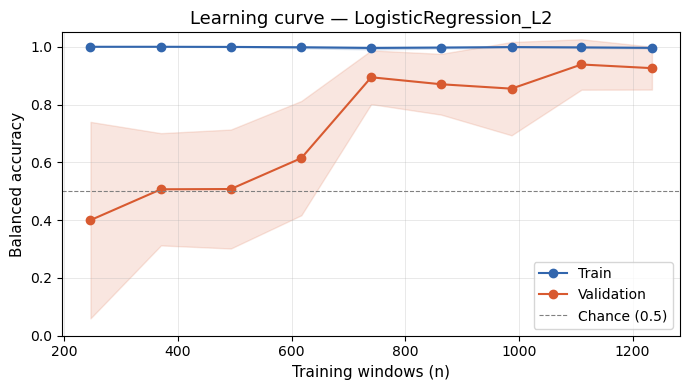

[LogisticRegression_L2] Validation curve verdict: still rising — consider collecting more windows


  SVM_regularized

[SVM_regularized] Fold 1: balanced_acc=0.897, macro_f1=0.869
[SVM_regularized] Fold 2: balanced_acc=0.843, macro_f1=0.858
[SVM_regularized] Fold 3: balanced_acc=0.800, macro_f1=0.739
[SVM_regularized] Fold 4: balanced_acc=0.838, macro_f1=0.847
[SVM_regularized] Fold 5: balanced_acc=0.977, macro_f1=0.982

[SVM_regularized] Mean balanced accuracy: 0.871 +/- 0.062
[SVM_regularized] Mean macro F1:           0.859 +/- 0.077

[SVM_regularized] Mean per-class recall across folds:
  RI1: 0.886 +/- 0.134
  RI2: 0.856 +/- 0.112

[SVM_regularized] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

         RI1       0.89      0.87      0.88       784
         RI2       0.86      0.88      0.87       737

    accuracy                           0.87      1521
   macro avg       0.87      0.87      0.87      1521
weighted a

,pred_RI1,pred_RI2
true_RI1,679,105
true_RI2,86,651


c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
2 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\thoma\miniconda3\envs\biopipeline-env\

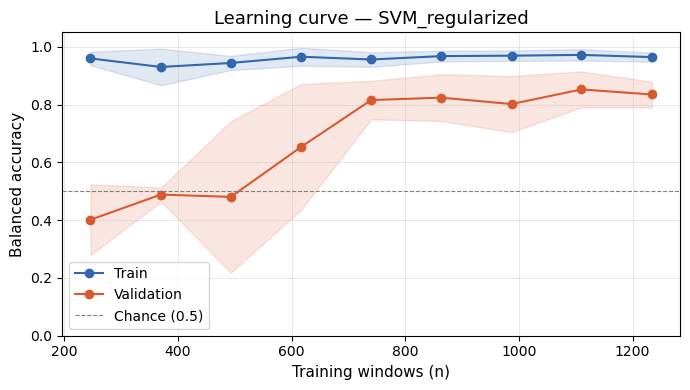

[SVM_regularized] Validation curve verdict: still rising — consider collecting more windows


  RandomForest_regularized

[RandomForest_regularized] Fold 1: balanced_acc=1.000, macro_f1=1.000
[RandomForest_regularized] Fold 2: balanced_acc=1.000, macro_f1=1.000
[RandomForest_regularized] Fold 3: balanced_acc=0.754, macro_f1=0.673
[RandomForest_regularized] Fold 4: balanced_acc=0.979, macro_f1=0.968
[RandomForest_regularized] Fold 5: balanced_acc=1.000, macro_f1=1.000

[RandomForest_regularized] Mean balanced accuracy: 0.947 +/- 0.097
[RandomForest_regularized] Mean macro F1:           0.928 +/- 0.128

[RandomForest_regularized] Mean per-class recall across folds:
  RI1: 0.893 +/- 0.193
  RI2: 1.000 +/- 0.000

[RandomForest_regularized] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

         RI1       1.00      0.87      0.93       784
         RI2       0.88      1.00      0.93       737

    accuracy                      

,pred_RI1,pred_RI2
true_RI1,679,105
true_RI2,0,737


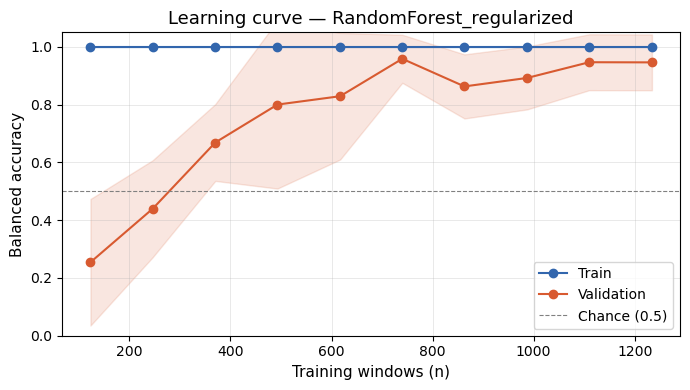

[RandomForest_regularized] Validation curve verdict: still rising — consider collecting more windows



In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import f1_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, learning_curve
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ── Explicitly regularized models ─────────────────────────────────────────────

# Add median imputation to handle occasional NaNs in respiratory features.
preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(
        penalty="l2",          # L2 regularization
        C=0.1,                 # smaller C = stronger regularization
        class_weight=None,     # using sample weights manually instead
        solver="liblinear",    # supports l1/l2 for smaller datasets
        max_iter=2000,
        random_state=42
    ))
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(
        kernel="rbf",
        C=0.1,                 # smaller C = stronger regularization
        gamma="scale",
        class_weight=None,     # using sample weights manually instead
        random_state=42
    ))
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=5,           # shallower trees = more regularization
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        bootstrap=True,
        class_weight=None,     # using sample weights manually instead
        random_state=42,
        n_jobs=-1
    ))
])

# ── CV setup ──────────────────────────────────────────────────────────────────

if groups is not None and pd.Series(groups).nunique() >= 3:
    n_splits_eval = min(5, pd.Series(groups).nunique())
    cv_eval = StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_eval_mode = f"StratifiedGroupKFold(n_splits={n_splits_eval}, shuffle=True)"
else:
    n_splits_eval = 5
    cv_eval = StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_eval_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

classes = np.sort(y.unique())
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
class_weight_map = dict(zip(classes, class_weights))
print(f"CV for evaluation: {cv_eval_mode}")
print("Computed balanced class weights:", class_weight_map)

# ── Split iterator factory ────────────────────────────────────────────────────

def make_split_iterator():
    if groups is not None and pd.Series(groups).nunique() >= 3:
        return StratifiedGroupKFold(
            n_splits=n_splits_eval, shuffle=True, random_state=42
        ).split(X, y, groups=groups)
    return StratifiedKFold(
        n_splits=n_splits_eval, shuffle=True, random_state=42
    ).split(X, y)

# ── Main evaluation function ──────────────────────────────────────────────────

def evaluate_imbalanced_pipeline(base_model, model_name, split_iterator):
    bal_acc_scores, macro_f1_scores = [], []
    per_class_recall = []
    y_true_all, y_pred_all = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        fold_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

        model = clone(base_model)
        model.fit(X_train, y_train, model__sample_weight=fold_sample_weights)

        y_pred = model.predict(X_test)

        present_classes = np.sort(y_test.unique())
        bal_acc = recall_score(
            y_test, y_pred, labels=present_classes, average="macro", zero_division=0
        )
        macro_f1 = f1_score(
            y_test, y_pred, labels=present_classes, average="macro", zero_division=0
        )

        fold_recalls = np.full(len(classes), np.nan)
        present_recalls = recall_score(
            y_test, y_pred, labels=present_classes, average=None, zero_division=0
        )
        for i, cls in enumerate(classes):
            if cls in present_classes:
                fold_recalls[i] = present_recalls[np.where(present_classes == cls)[0][0]]

        bal_acc_scores.append(bal_acc)
        macro_f1_scores.append(macro_f1)
        per_class_recall.append(fold_recalls)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(f"[{model_name}] Fold {fold_idx}: balanced_acc={bal_acc:.3f}, macro_f1={macro_f1:.3f}")

    per_class_recall = np.array(per_class_recall, dtype=float)

    print(f"\n[{model_name}] Mean balanced accuracy: {np.mean(bal_acc_scores):.3f} +/- {np.std(bal_acc_scores):.3f}")
    print(f"[{model_name}] Mean macro F1:           {np.mean(macro_f1_scores):.3f} +/- {np.std(macro_f1_scores):.3f}")

    print(f"\n[{model_name}] Mean per-class recall across folds:")
    for i, cls in enumerate(classes):
        cls_mean = np.nanmean(per_class_recall[:, i])
        cls_std  = np.nanstd(per_class_recall[:, i])
        print(f"  {cls}: {cls_mean:.3f} +/- {cls_std:.3f}")

    print(f"\n[{model_name}] Classification report (pooled out-of-fold predictions):")
    print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in classes],
        columns=[f"pred_{c}" for c in classes]
    )
    display(cm_df)

# ── Learning curve function ───────────────────────────────────────────────────

def plot_learning_curve(base_model, model_name, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    Plots training vs. validation balanced accuracy as a function of training set size.

    How to read it:
      - Large gap between train and val  →  overfitting (need more data or regularisation)
      - Both curves flat and low         →  underfitting (model too simple)
      - Val curve still rising at 100%   →  you need more windows
      - Val curve flattened              →  adding more data won't help much
    """

    cv_lc = (
        StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
        if groups is not None and pd.Series(groups).nunique() >= 3
        else StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    )

    lc_kwargs = dict(
        estimator=base_model,
        X=X,
        y=y,
        cv=cv_lc,
        scoring="balanced_accuracy",
        train_sizes=train_sizes,
        n_jobs=-1,
        return_times=False,
    )
    if groups is not None and pd.Series(groups).nunique() >= 3:
        lc_kwargs["groups"] = groups

    train_sizes_abs, train_scores, val_scores = learning_curve(**lc_kwargs)

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_sizes_abs, train_mean, "o-", color="#3266ad", label="Train")
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#3266ad")
    ax.plot(train_sizes_abs, val_mean, "o-", color="#d85a30", label="Validation")
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#d85a30")

    ax.set_title(f"Learning curve — {model_name}", fontsize=13)
    ax.set_xlabel("Training windows (n)", fontsize=11)
    ax.set_ylabel("Balanced accuracy", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance (0.5)")
    ax.legend(fontsize=10)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    plt.tight_layout()
    plt.show()

    val_slope = val_mean[-1] - val_mean[-3]
    if val_slope > 0.02:
        verdict = "still rising — consider collecting more windows"
    elif val_mean[-1] < 0.55:
        verdict = "flat but low — model may need different features, not more data"
    else:
        verdict = "flattened — data volume looks sufficient for this model"
    print(f"[{model_name}] Validation curve verdict: {verdict}\n")

# ── Run everything ────────────────────────────────────────────────────────────

for model, name in [(logreg_clf, "LogisticRegression_L2"),
                    (svm_clf,    "SVM_regularized"),
                    (rf_clf,     "RandomForest_regularized")]:

    print(f"\n{'='*80}")
    print(f"  {name}")
    print(f"{'='*80}\n")

    evaluate_imbalanced_pipeline(model, name, make_split_iterator())
    print()
    plot_learning_curve(model, name)

In [8]:
# NaN audit + drop columns/rows with excessive missingness
COL_NAN_THRESHOLD = 0.40
ROW_NAN_THRESHOLD = 0.40

nan_by_col = feature_matrix.isna().sum().sort_values(ascending=False)
nan_by_row = feature_matrix.isna().sum(axis=1)

total_nans = int(nan_by_col.sum())
col_nan_frac = feature_matrix.isna().mean(axis=0)
row_nan_frac = feature_matrix.isna().mean(axis=1)

cols_to_drop = col_nan_frac[col_nan_frac > COL_NAN_THRESHOLD].index.tolist()
rows_to_drop = row_nan_frac[row_nan_frac > ROW_NAN_THRESHOLD].index.tolist()

feature_matrix_clean = (
    feature_matrix
    .drop(columns=cols_to_drop)
    .drop(index=rows_to_drop)
    .reset_index(drop=True)
)

print(f"Total NaNs in feature_matrix: {total_nans}")
print(f"Columns with >=1 NaN: {(nan_by_col > 0).sum()} / {feature_matrix.shape[1]}")
print(f"Rows with >=1 NaN: {(nan_by_row > 0).sum()} / {feature_matrix.shape[0]}\n")

print(f"Columns dropped (> {COL_NAN_THRESHOLD:.0%} NaN): {len(cols_to_drop)}")
if cols_to_drop:
    display(col_nan_frac.loc[cols_to_drop].sort_values(ascending=False).to_frame("nan_fraction"))

print(f"Rows dropped (> {ROW_NAN_THRESHOLD:.0%} NaN): {len(rows_to_drop)}")
print(f"Original shape: {feature_matrix.shape}")
print(f"Cleaned shape: {feature_matrix_clean.shape}")

Total NaNs in feature_matrix: 9782
Columns with >=1 NaN: 8 / 45
Rows with >=1 NaN: 2160 / 2215

Columns dropped (> 40% NaN): 8


,nan_fraction
cv_inhale_pause_dur,0.911061
n_bouts_anogenital_sniffing,0.574718
total_dur_anogenital_sniffing,0.574718
cv_exhale_pause_dur,0.560722
n_bouts_body_sniffing,0.493905
total_dur_body_sniffing,0.493905
n_bouts_facial_sniffing,0.403612
total_dur_facial_sniffing,0.403612


Rows dropped (> 40% NaN): 0
Original shape: (2215, 45)
Cleaned shape: (2215, 37)


In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import RUSBoostClassifier

# Use cleaned matrix only when it is row-aligned with y and has matching feature columns.
if "feature_matrix_clean" in globals() and len(feature_matrix_clean) == len(y):
    safe_cols = [c for c in kept_feature_cols if c in feature_matrix_clean.columns]
    X_search = feature_matrix_clean[safe_cols].copy()
else:
    X_search = X.copy()
y_search = y.copy()

# Keep groups aligned with X_search rows when possible.
if groups is not None and len(groups) == len(X_search):
    groups_search = groups.copy()
else:
    groups_search = None

search_scoring = "balanced_accuracy"

models_and_grids = {
    "LogisticRegression": (
        Pipeline([
            ("preprocess", preprocess_numeric),
            ("model", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs")),
        ]),
        {
            "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        },
    ),
    "SVM": (
        Pipeline([
            ("preprocess", preprocess_numeric),
            ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
        ]),
        {
            "model__C": [0.1, 1.0, 10.0, 100.0],
            "model__gamma": ["scale", 0.01, 0.1, 1.0],
        },
    ),
    "RandomForest": (
        Pipeline([
            ("preprocess", preprocess_impute_only),
            ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
        ]),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 8, 16],
            "model__min_samples_leaf": [1, 3, 5],
            "model__max_features": ["sqrt", 0.5],
        },
    ),
    "RUSBoost": (
        Pipeline([
            ("preprocess", preprocess_impute_only),
            (
                "model",
                RUSBoostClassifier(
                    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
                    random_state=42,
                    algorithm="SAMME",
                ),
            ),
        ]),
        {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.05, 0.1, 0.5, 1.0],
            "model__sampling_strategy": ["auto", "not minority", "all"],
            "model__replacement": [False, True],
            "model__estimator": [
                DecisionTreeClassifier(max_depth=1, random_state=42),
                DecisionTreeClassifier(max_depth=2, random_state=42),
            ],
        },
    ),
}

grid_search_results = {}

for model_name, (pipe, param_grid) in models_and_grids.items():
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=search_scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )

    if groups_search is not None and hasattr(cv, "split"):
        gs.fit(X_search, y_search, groups=groups_search)
    else:
        gs.fit(X_search, y_search)

    grid_search_results[model_name] = {
        "best_estimator": gs.best_estimator_,
        "best_score": gs.best_score_,
        "best_params": gs.best_params_,
    }

results_df = pd.DataFrame(
    {
        model: {
            "best_balanced_accuracy_cv": vals["best_score"],
            "best_params": vals["best_params"],
        }
        for model, vals in grid_search_results.items()
    }
).T.sort_values("best_balanced_accuracy_cv", ascending=False)

print("Grid search complete (scoring=balanced_accuracy)")
display(results_df)

for model_name, vals in grid_search_results.items():
    print(f"\n{model_name} best CV balanced_accuracy: {vals['best_score']:.4f}")
    print(f"{model_name} best params: {vals['best_params']}")

Grid search complete (scoring=balanced_accuracy)


c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\imblearn\ensemble\_weight_boosting.py:403: FutureWarning: `algorithm` parameter is deprecated in 0.12 and will be removed in 0.14. In the future, the SAMME algorithm will always be used.
  warnings.warn(


,best_balanced_accuracy_cv,best_params
LogisticRegression,0.973562,{'model__C': 100.0}
RandomForest,0.965079,"{'model__max_depth': 8, 'model__max_features':..."
SVM,0.905822,"{'model__C': 10.0, 'model__gamma': 'scale'}"
RUSBoost,0.882952,{'model__estimator': DecisionTreeClassifier(ma...



LogisticRegression best CV balanced_accuracy: 0.9736
LogisticRegression best params: {'model__C': 100.0}

SVM best CV balanced_accuracy: 0.9058
SVM best params: {'model__C': 10.0, 'model__gamma': 'scale'}

RandomForest best CV balanced_accuracy: 0.9651
RandomForest best params: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 200}

RUSBoost best CV balanced_accuracy: 0.8830
RUSBoost best params: {'model__estimator': DecisionTreeClassifier(max_depth=1, random_state=42), 'model__learning_rate': 0.05, 'model__n_estimators': 50, 'model__replacement': False, 'model__sampling_strategy': 'auto'}
